#Trabajo final Herramientas básicas para el Análisis de Datos

##Explicación del Proyecto.

Buscando Datasets encontré un Dataset en Kaggle llamado "Everest & the Death Zone — Will They Summit?"

Dado que tengo el sueño de escalar el Everest quise hacer un proytecto para analizar el historial de excursiones con el objetivo de encontrar cuales son los factores que aumentan las posibilidades de una excursión exitosa.

###Preguntas a responder.
1. ¿Cuál es el porcentaje de éxito total de las excursiones?
2. ¿Cuántas excursiones se realizan al año? ¿Las probabilidades de éxito aumentaron?
3. ¿Cuánto cuesta escalar el everest?
4. ¿La probabilidad de muerte es muy alta?
5. ¿Cómo puedo aumentar la probabilidad de que realice una excursión exitosa?


##Preparación del entorno de Trabajo.

### Importo Drive

In [110]:
##Primero Importo las librerías y el dataset.
from google.colab import drive
drive.mount

<function google.colab.drive.mount(mountpoint, force_remount=False, timeout_ms=120000, readonly=False)>

###Dejo Herramientas y Data Set

In [111]:
##Importo librería y dataset.
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Herramientas Básicas UTN/Trabajo Final/everest_summit_master.csv')

#Herramientas gráficas.

import seaborn as sns
import matplotlib.pyplot as plt

###Dejo el diccionario legible y en español.

In [112]:
##Importo el diccionario para tenerlo a mano.
diccionario = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Herramientas Básicas UTN/Trabajo Final/data_dictionary.csv')

diccionario

,column,type,description
0,climber_id,string,Unique climber-attempt id
1,year,int,Year of the attempt (1990-2026)
2,season,string,spring / autumn / winter / summer (~86% spring)
3,route,string,South Col-SE Ridge (Nepal) / North Ridge-NE (T...
4,age,int,Climber age
5,sex,string,M / F
6,is_hired_staff,int,1 if hired high-altitude worker (e.g. Sherpa s...
7,years_climbing,int,Years of climbing experience
8,prior_8000m_peaks,int,Number of 8000m peaks previously summited — th...
9,prior_everest_attempts,int,Previous Everest attempts


In [113]:
##Al ver que está en inglés le pedí a la IA que me haga el diccionario en csv así lo veo más intuitivamente.
csv_text = """column,type,description
climber_id,string,ID único de cada intento de ascenso
year,int,Año del intento
season,string,Temporada de la expedición
route,string,Ruta utilizada para el ascenso
age,int,Edad del montañista
sex,string,Sexo del montañista
is_hired_staff,int,Personal de alta montaña contratado (1=Sí)
years_climbing,int,Años de experiencia en montañismo
prior_8000m_peaks,int,Cantidad de cumbres de más de 8000 m logradas previamente
prior_everest_attempts,int,Número de intentos previos al Everest
highest_prev_altitude_m,int,Mayor altitud alcanzada antes del intento (m)
operator_tier,string,Categoría del operador de la expedición
team_size,int,Cantidad de integrantes del equipo
sherpa_ratio,float,Cantidad de personal de apoyo por cliente
uses_oxygen,int,Uso de oxígeno suplementario (1=Sí)
o2_start_altitude_m,int,Altitud de inicio del uso de oxígeno (m)
days_acclimatizing,int,Días de aclimatación antes del ascenso final
camps_established,int,Cantidad de campamentos establecidos
summit_window_days,int,Días disponibles para intentar la cumbre
weather_score,float,Calidad de las condiciones climáticas (0-10)
jetstream_risk,float,Riesgo asociado a la corriente en chorro (0-10)
queue_minutes_above_8000,int,Minutos de espera por encima de 8000 m
turnaround_reason,string,Motivo de abandono o cumbre alcanzada
serious_incident,int,Incidente grave durante la expedición (1=Sí)
summited,int,Objetivo: alcanzó la cumbre (1=Sí)"""

with open("/content/drive/MyDrive/Colab Notebooks/Herramientas Básicas UTN/Trabajo Final/Diccionario Traducido.csv", "w", encoding="utf-8") as f:
  f.write(csv_text)

diccionario = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Herramientas Básicas UTN/Trabajo Final/Diccionario Traducido.csv")

diccionario

,column,type,description
0,climber_id,string,ID único de cada intento de ascenso
1,year,int,Año del intento
2,season,string,Temporada de la expedición
3,route,string,Ruta utilizada para el ascenso
4,age,int,Edad del montañista
5,sex,string,Sexo del montañista
6,is_hired_staff,int,Personal de alta montaña contratado (1=Sí)
7,years_climbing,int,Años de experiencia en montañismo
8,prior_8000m_peaks,int,Cantidad de cumbres de más de 8000 m logradas ...
9,prior_everest_attempts,int,Número de intentos previos al Everest


##Empezamos con el Análisis exploratorio.

In [114]:
df.head()

#Visualizó las columnas
#Se observa que para responder mis preguntas necesito las columnas:
#year
#uses_oxygen
#o2_start_altitude_m
#prior_everest_attempts
#turnaround_reason
#summited

#El resto será eliminado

,climber_id,year,season,route,age,sex,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,...,o2_start_altitude_m,days_acclimatizing,camps_established,summit_window_days,weather_score,jetstream_risk,queue_minutes_above_8000,turnaround_reason,serious_incident,summited
0,CLB000000,2025,spring,South Col-SE Ridge,56,M,0,15,0,1,...,7000,29,6,5,10.0,1.3,120,other,0,0
1,CLB000001,2020,spring,North Ridge-NE,47,M,0,7,0,1,...,7900,27,4,5,4.8,4.7,26,summited,0,1
2,CLB000002,2022,autumn,South Col-SE Ridge,24,M,1,19,1,0,...,7000,29,3,3,8.6,1.6,37,summited,0,1
3,CLB000003,2024,spring,South Col-SE Ridge,50,F,0,12,3,0,...,7000,35,2,6,5.9,3.0,45,team_decision,0,0
4,CLB000004,2015,spring,North Ridge-NE,60,F,0,1,1,0,...,7300,20,1,7,6.7,2.7,20,exhaustion_altitude_sickness,0,0


In [115]:
df.info()

#Se observa que no hay datos nulos.
#Columnas: 25.
#Filas: 45 mil.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   climber_id                45000 non-null  object 
 1   year                      45000 non-null  int64  
 2   season                    45000 non-null  object 
 3   route                     45000 non-null  object 
 4   age                       45000 non-null  int64  
 5   sex                       45000 non-null  object 
 6   is_hired_staff            45000 non-null  int64  
 7   years_climbing            45000 non-null  int64  
 8   prior_8000m_peaks         45000 non-null  int64  
 9   prior_everest_attempts    45000 non-null  int64  
 10  highest_prev_altitude_m   45000 non-null  int64  
 11  operator_tier             45000 non-null  object 
 12  team_size                 45000 non-null  int64  
 13  sherpa_ratio              45000 non-null  float64
 14  uses_o

In [116]:
df.describe()

,year,age,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,highest_prev_altitude_m,team_size,sherpa_ratio,uses_oxygen,o2_start_altitude_m,days_acclimatizing,camps_established,summit_window_days,weather_score,jetstream_risk,queue_minutes_above_8000,serious_incident,summited
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,2011.782089,37.976267,0.300178,11.066800,2.094333,0.403289,7638.613733,9.008867,0.961231,0.933867,6958.220000,31.985911,3.416667,4.986711,6.185876,3.845589,38.436667,0.021889,0.380422
std,9.996894,9.911736,0.458340,5.850655,2.146538,0.738371,881.698476,2.839803,0.540438,0.248518,1888.932253,7.011293,1.592301,2.013842,1.947352,2.210480,46.656211,0.146322,0.485496
min,1990.000000,16.000000,0.000000,0.000000,0.000000,0.000000,4000.000000,1.000000,0.000000,0.000000,0.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2004.000000,31.000000,0.000000,7.000000,0.000000,0.000000,7359.000000,7.000000,0.550000,1.000000,7000.000000,27.000000,2.000000,4.000000,4.900000,2.200000,7.000000,0.000000,0.000000
50%,2013.000000,38.000000,0.000000,11.000000,1.000000,0.000000,7950.000000,9.000000,0.900000,1.000000,7300.000000,32.000000,3.000000,5.000000,6.200000,3.800000,20.000000,0.000000,0.000000
75%,2020.000000,45.000000,1.000000,15.000000,3.000000,1.000000,8217.000000,11.000000,1.330000,1.000000,7900.000000,37.000000,5.000000,6.000000,7.600000,5.400000,52.000000,0.000000,1.000000
max,2026.000000,78.000000,1.000000,35.000000,11.000000,3.000000,8800.000000,22.000000,3.000000,1.000000,8000.000000,58.000000,6.000000,12.000000,10.000000,10.000000,420.000000,1.000000,1.000000


### Primeras Observaciones.
Se puede ver que:


*   Se han acumulado datos desde 1990.
*   Si bien los rangos de edad de las personas que escalan el Monte Everest es extenso la media se ubica en la edad de 37.9 años, 38 redondeando.
*   Se contratan guías en alrededor del 30% de las excursiones, esto indicado por la media.
*   Por lo general la media de años de una persona que escala el everest es de 11 años, sin embargo también lo ha hecho gente sin experiencia.
*   Se observa que la mayoría de los valores estadísticos de la columna de intentos antes de lograr la cima está por debajo del valor 1.0, por lo cual se estima que el porcentaje de casos exitosos puede ser alto. Sin embargo esta estimación no tiene en cuenta personas que lo intentaron y nunca más volvieron a intentarlo.
* Se observa que la media de summited está en el 0.38, por lo cual se intuye que el 38% de las excursiones son exitosas.
*   No se visualizan Outliers


### Cambio de preguntas al ver el tipo de datos.
1. ¿Cuál es el porcentaje de éxito total de las excursiones?
2. ¿Cuántas excursiones se realizan al año? ¿Las probabilidades de éxito aumentaron?
3. ¿Cuál es la ruta que más éxito tiene? ¿La estación también influte en el éxito?
4. ¿Qué factores se repiten en los motivos de abandono de la travesía?


##Limpieza del Dataset.

###Eliminación de las columnas innecesarias.

In [117]:
#Elimino columnas para trabajar sólo con las columnas que me interesan para
#realizar el análisis
columnas = [
'year',
'uses_oxygen',
'o2_start_altitude_m',
'climber_id',
'season',
'route',
'is_hired_staff',
'years_climbing',
'prior_everest_attempts',
'turnaround_reason',
'summited']
df_analisis = df[columnas].copy()
# Verificación
print(df_analisis.shape)
df_analisis.head()

#Me quedan las 7 columnas elegidas.

(45000, 11)


,year,uses_oxygen,o2_start_altitude_m,climber_id,season,route,is_hired_staff,years_climbing,prior_everest_attempts,turnaround_reason,summited
0,2025,1,7000,CLB000000,spring,South Col-SE Ridge,0,15,1,other,0
1,2020,1,7900,CLB000001,spring,North Ridge-NE,0,7,1,summited,1
2,2022,1,7000,CLB000002,autumn,South Col-SE Ridge,1,19,0,summited,1
3,2024,1,7000,CLB000003,spring,South Col-SE Ridge,0,12,0,team_decision,0
4,2015,1,7300,CLB000004,spring,North Ridge-NE,0,1,0,exhaustion_altitude_sickness,0


###Identificación de Nulos

In [118]:
#Identifico si hay nulos
df_analisis.isnull().sum()
#No los hay.

,0
year,0
uses_oxygen,0
o2_start_altitude_m,0
climber_id,0
season,0
route,0
is_hired_staff,0
years_climbing,0
prior_everest_attempts,0
turnaround_reason,0


###Hay duplicados?

In [119]:
##No hay duplicados
df_analisis.duplicated().sum()

np.int64(0)

###Exploración de los valores para identificar si ya se puede trabajar.

In [120]:
#Quiero ver cuales son las rutas disponibles.
df_analisis['route'].value_counts()
#Observo que hay 2 rutas disponibles y otra clasificación llamada "other"
#Dado que es una montaña inmensa es posible que existan caminos distintos a los comerciales o normales.
#Other es un porcentaje significativo así que lo dejaré la columna tal como está para responder mis preguntas y agregar otras.


,count
route,
South Col-SE Ridge,29670
North Ridge-NE,13993
other,1337


In [121]:
#Info del resto de las columnas para ya visualizar todos los parámetros y ver que todo encaje.
for columna in [
'year',
'uses_oxygen',
'o2_start_altitude_m',
'season',
'route',
'is_hired_staff',
'years_climbing',
'prior_everest_attempts',
'turnaround_reason',
'summited']:
    print(f"\n\n{columna.upper()}")
    print(df_analisis[columna].value_counts())



YEAR
year
2024    1957
2026    1916
2023    1885
2025    1819
2022    1814
2021    1784
2020    1713
2019    1594
2018    1591
2017    1558
2016    1544
2014    1447
2015    1440
2012    1407
2013    1375
2010    1351
2011    1343
2009    1317
2007    1188
2008    1181
2005    1113
2006    1063
2003    1032
2004    1031
2002     993
2000     937
2001     916
1999     853
1996     766
1998     764
1997     740
1995     675
1994     658
1993     626
1992     588
1991     536
1990     485
Name: count, dtype: int64


USES_OXYGEN
uses_oxygen
1    42024
0     2976
Name: count, dtype: int64


O2_START_ALTITUDE_M
o2_start_altitude_m
7300    14315
7900    12576
7000    11794
8000     3339
0        2976
Name: count, dtype: int64


SEASON
season
spring    38694
autumn     4999
winter      864
summer      443
Name: count, dtype: int64


ROUTE
route
South Col-SE Ridge    29670
North Ridge-NE        13993
other                  1337
Name: count, dtype: int64


IS_HIRED_STAFF
is_hired_staff
0    31

###No se observaron valores atípicos o incongruentes por lo cual pasaremos a la manipulación.

##Exploración y Visualización.
Lo realizaremos intentando responder directamente las preguntas planteadas.

### Pregunta 1.

Pregunta: ¿Cuál es el porcentaje de éxito total de las excursiones?


####Análisis.

In [122]:
#Para esto tengo que ver que porcentaje del total de la columna "summited" tiene valor 0 y 1
#0= No llegó a la cima  1= Llegó a la cima
Porcentaje_exitoso = (df_analisis['summited'].value_counts(normalize=True) * 100).round(2)
print("Porcentaje de expediciones exitosas y no exitosas:")
print(Porcentaje_exitoso)

#Nos dice que el 38.04% de las excursiones fueron exitosas mientras que el 61.96% no cumplió el objetivo.

Porcentaje de expediciones exitosas y no exitosas:
summited
0    61.96
1    38.04
Name: proportion, dtype: float64


####Gráfico.

/tmp/ipykernel_1952/871437107.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summited_counts.index, y=summited_counts.values, palette='viridis')


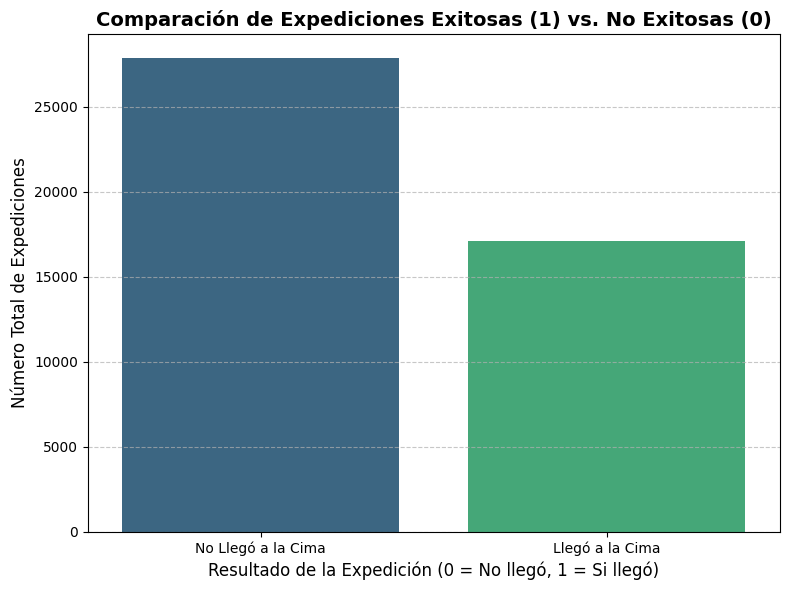

,count
summited,
0,27881
1,17119


In [123]:
#Utilizo un gráfico de Barras para que se note mejor la diferencia entre cada valor.

plt.figure(figsize=(8, 6))
sns.barplot(x=summited_counts.index, y=summited_counts.values, palette='viridis')
plt.title('Comparación de Expediciones Exitosas (1) vs. No Exitosas (0)', fontsize=14, fontweight='bold')
plt.xlabel('Resultado de la Expedición (0 = No llegó, 1 = Si llegó)', fontsize=12)
plt.ylabel('Número Total de Expediciones', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Llegó a la Cima', 'Llegó a la Cima'], fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

df_analisis['summited'].value_counts()

Como conclusión se puede observar que poco más de la mitad de las excursiones al Monte Everest completan el recorrido. con 27.881 fracasos contra 17.119 éxitos.

###Pregunta 2.
¿Cuántas excursiones se realizan al año? ¿Las probabilidades de éxito aumentaron?


####Análisis.

In [128]:
#Quiero ver la cantidad de expediciones que hubieron por año.
expediciones_anuales = df_analisis['year'].value_counts().sort_index()
print("Cantidad de excursiones por año:")
print(expediciones_anuales)

Cantidad de excursiones por año:
year
1990     485
1991     536
1992     588
1993     626
1994     658
1995     675
1996     766
1997     740
1998     764
1999     853
2000     937
2001     916
2002     993
2003    1032
2004    1031
2005    1113
2006    1063
2007    1188
2008    1181
2009    1317
2010    1351
2011    1343
2012    1407
2013    1375
2014    1447
2015    1440
2016    1544
2017    1558
2018    1591
2019    1594
2020    1713
2021    1784
2022    1814
2023    1885
2024    1957
2025    1819
2026    1916
Name: count, dtype: int64


In [138]:
#De paso veremos el promedio de expedición por año.
expediciones_anuales = df_analisis['year'].value_counts()
print(expediciones_anuales)
# Promedio de esas cantidades
promedio_expediciones = expediciones_anuales.mean()
print(f"Promedio de expediciones por año: {promedio_expediciones:.1f}")

#Se llega a la conclusión de que hay en promedio, desde el año 1990, 1216 expediciones.
#Registrando  sólo el último año 1957

year
2024    1957
2026    1916
2023    1885
2025    1819
2022    1814
2021    1784
2020    1713
2019    1594
2018    1591
2017    1558
2016    1544
2014    1447
2015    1440
2012    1407
2013    1375
2010    1351
2011    1343
2009    1317
2007    1188
2008    1181
2005    1113
2006    1063
2003    1032
2004    1031
2002     993
2000     937
2001     916
1999     853
1996     766
1998     764
1997     740
1995     675
1994     658
1993     626
1992     588
1991     536
1990     485
Name: count, dtype: int64
Promedio de expediciones por año: 1216.2


In [143]:
# Hago un grupo para guardar y analizar los nuevos valores que voy a crear.
exitos_anuales = df_analisis.groupby('year')['summited'].value_counts().unstack().fillna(0)

# Les pongo nombre claro a las columnas.
exitos_anuales.rename(columns={0: 'No_Exitosas', 1: 'Exitosas'}, inplace=True)

# Le digo que calcule y guarde en una columna nueva el total de expediciones por año.
exitos_anuales['Total_Expediciones'] = exitos_anuales['No_Exitosas'] + exitos_anuales['Exitosas']

# Calculo la probabilidad de éxito (en porcentaje)
exitos_anuales['Probabilidad_Exito'] = (exitos_anuales['Exitosas'] / exitos_anuales['Total_Expediciones']) * 100

# Mostrar los resultados
print(exitos_anuales.round(2))

#A simple vista pareciera que no hay mucha diferencia.

summited  No_Exitosas  Exitosas  Total_Expediciones  Probabilidad_Exito
year                                                                   
1990              310       175                 485               36.08
1991              357       179                 536               33.40
1992              353       235                 588               39.97
1993              388       238                 626               38.02
1994              396       262                 658               39.82
1995              413       262                 675               38.81
1996              462       304                 766               39.69
1997              469       271                 740               36.62
1998              484       280                 764               36.65
1999              541       312                 853               36.58
2000              547       390                 937               41.62
2001              542       374                 916             

####Gráfico.

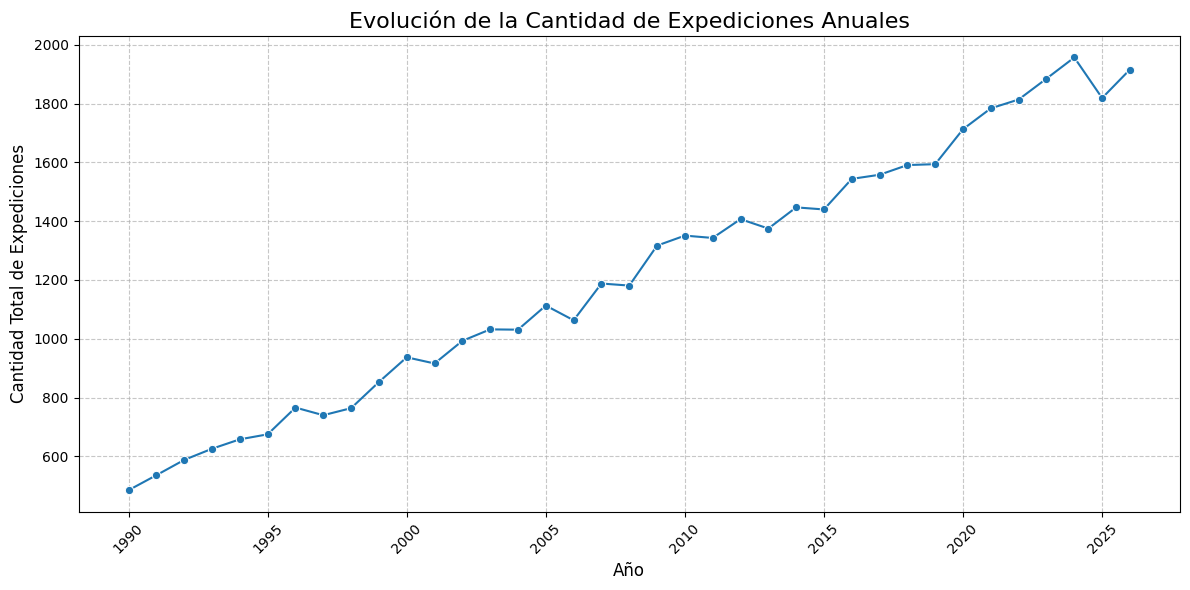

In [147]:
#Ahora quiero un gráfico que me muestre la evolución de la cantidad de excursiones anuales.

plt.figure(figsize=(12, 6))
sns.lineplot(x=exitos_anuales.index, y=exitos_anuales['Total_Expediciones'], marker='o')
plt.title('Evolución de la Cantidad de Expediciones Anuales', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad Total de Expediciones', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Por lo que se aprecia el aumento fue continuo sin muchas caidas a excepción del 2024.

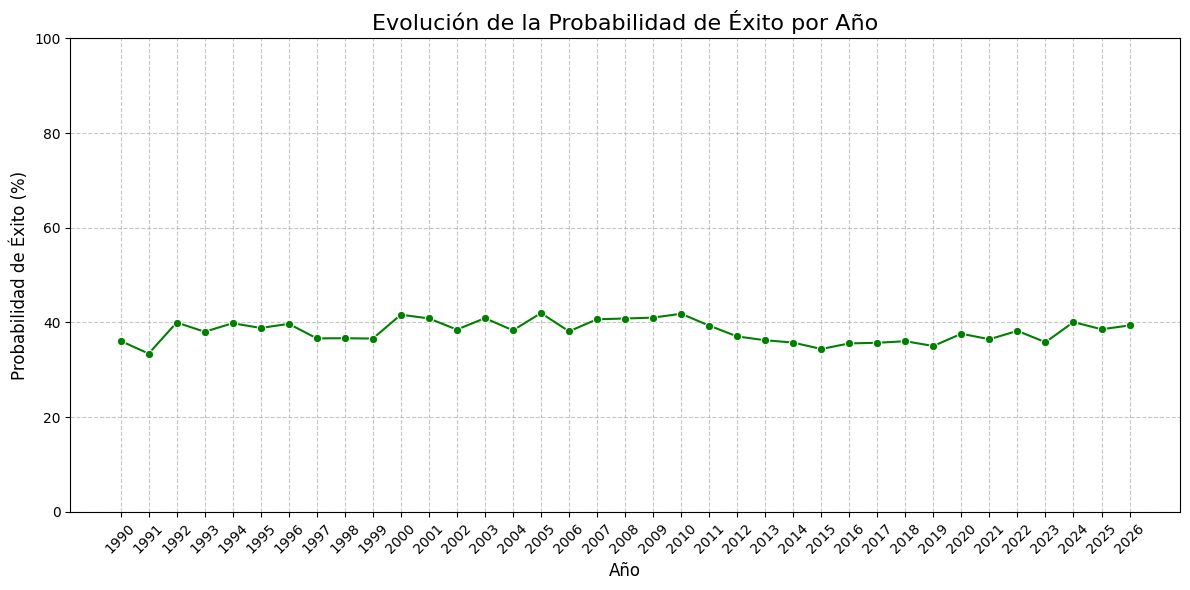

In [151]:
#Y para responder la segunda pregunta veremos un gráfico similar pero para la probabilidad de éxito en cada año, por lo que será en una escala del 0 al 100.
plt.figure(figsize=(12, 6))
sns.lineplot(
x=exitos_anuales.index,
y=exitos_anuales['Probabilidad_Exito'],
marker='o',
color='green')
plt.title('Evolución de la Probabilidad de Éxito por Año', fontsize=16)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Probabilidad de Éxito (%)', fontsize=12)
plt.xticks(exitos_anuales.index, rotation=45)
# Ajustar el rango para que se aprecien mejor las variaciones
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Se puede observar que la probabilidad se mantuvo estable, con un leve aumento hasta el 2010.
#luego fue descendiendo en el 2015 hasta recuperar mejores valores de éxito en el 2023.

En base a lo observado se estima que si bien la cantidad de excursiones aumentaron, generando más conocimiento y experiencia en lo necesario para una mejor travesía, el porcentaje de excursiones exitosas no aumento lo esperado.

###Pregunta 3.
¿Cuál es la ruta que más éxito tiene? ¿La estación también influte en el éxito?

####Análisis.

In [ ]:
#Para responder esta pregunta tengo que calcular el porcentaje de éxitos en las distintas rutas.


In [154]:
#Para responder esta pregunta tengo que calcular el porcentaje de éxitos en las distintas rutas.

porcentaje_exito_por_ruta = df_analisis.groupby('route')['summited'].mean() * 100
display(porcentaje_exito_por_ruta.round(2))

#Se observa que las 3 rutas tienen una similar probabilidad de éxito.

,summited
route,
North Ridge-NE,37.11
South Col-SE Ridge,38.45
other,38.82


In [157]:
#Haremoms lo mismo pero con la estación del año.
porcentaje_exito_por_estacion = df_analisis.groupby('season')['summited'].mean() * 100
display(porcentaje_exito_por_estacion.round(2))

#Se observa que hay una diferencia de éxito de casi el 10% entre intentarlo en invierno y en verano.

,summited
season,
autumn,34.77
spring,38.57
summer,40.63
winter,31.83


####Gráficos.

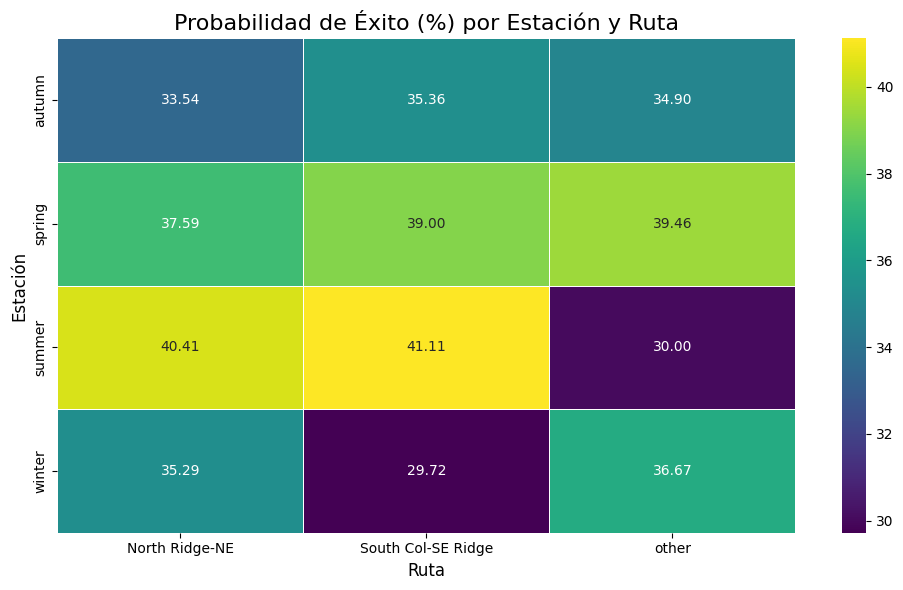

In [160]:
#En este caso veo que las probabilidades no difieren mucho, a excepción de lo que remarqué de el invierno y el verano.
#Haré una comparación entre las rutas y la estación para ver si hay alguna correlación usando heatmap.

#Creo el grupo que se va a comparar.
probabilidad_exito_ruta_estacion = df_analisis.groupby(['season', 'route'])['summited'].mean() * 100

#Creo que parámetro que usaré para gráficar.
probabilidad_exito_pivot = probabilidad_exito_ruta_estacion.unstack(level='route')

#Heatmap.
plt.figure(figsize=(10, 6))
sns.heatmap(probabilidad_exito_pivot, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
plt.title('Probabilidad de Éxito (%) por Estación y Ruta', fontsize=16)
plt.xlabel('Ruta', fontsize=12)
plt.ylabel('Estación', fontsize=12)
plt.tight_layout()
plt.show()

#Se puede observar que en general siempre es más seguro hacer la travesía en verano por las rutas principales.
#Las rutas no tageadas por algún motivo son mucho más peligrosas en general en el verano.
#Si bien la ruta sur en verano, primaver y otoño tiene mayor probabilidad de éxito, en invierno decae bruscamente.
#Estimo que el aumento de peligro de la ruta sur en invierno se debe a cambios ocasionados por la nieve o tormentas.

Se llega a la conclusíon de que el verano es el mejor momento para subir el Everest aumentando probabilidades subiendo por los lados Norte y Sur.

###Pregunta 4
¿Qué factores se repiten en los motivos de abandono de la travesía?

####Análisis

In [162]:
#Necesito ver los motivos y el porcentaje de motivos por los cuales se abandona la travesía.

print('Conteo de motivos de abandono:')
display(df_analisis['turnaround_reason'].value_counts())

print('\nPorcentaje de motivos de abandono:')
display((df_analisis['turnaround_reason'].value_counts(normalize=True) * 100).round(2))

Conteo de motivos de abandono:


,count
turnaround_reason,
summited,17119
weather_window_closed,8338
exhaustion_altitude_sickness,6988
team_decision,3585
frostbite,2809
illness,2612
other,1600
oxygen_exhaustion,1099
death_zone_crowding,850



Porcentaje de motivos de abandono:


,proportion
turnaround_reason,
summited,38.04
weather_window_closed,18.53
exhaustion_altitude_sickness,15.53
team_decision,7.97
frostbite,6.24
illness,5.80
other,3.56
oxygen_exhaustion,2.44
death_zone_crowding,1.89


Dejo diccionario a mano.
* summited = Alcanzó la cima
* weather_window_closed = Ventana climática cerrada
* exhaustion_altitude_sickness = Agotamiento o mal de altura
* team_decision = Decisión del equipo
* frostbite = Congelación
* illness = Enfermedad
* other = Otros
* oxygen_exhaustion = Agotamiento del oxígeno
* death_zone_crowding = Congestión en la zona de la muerte


####Gráfico

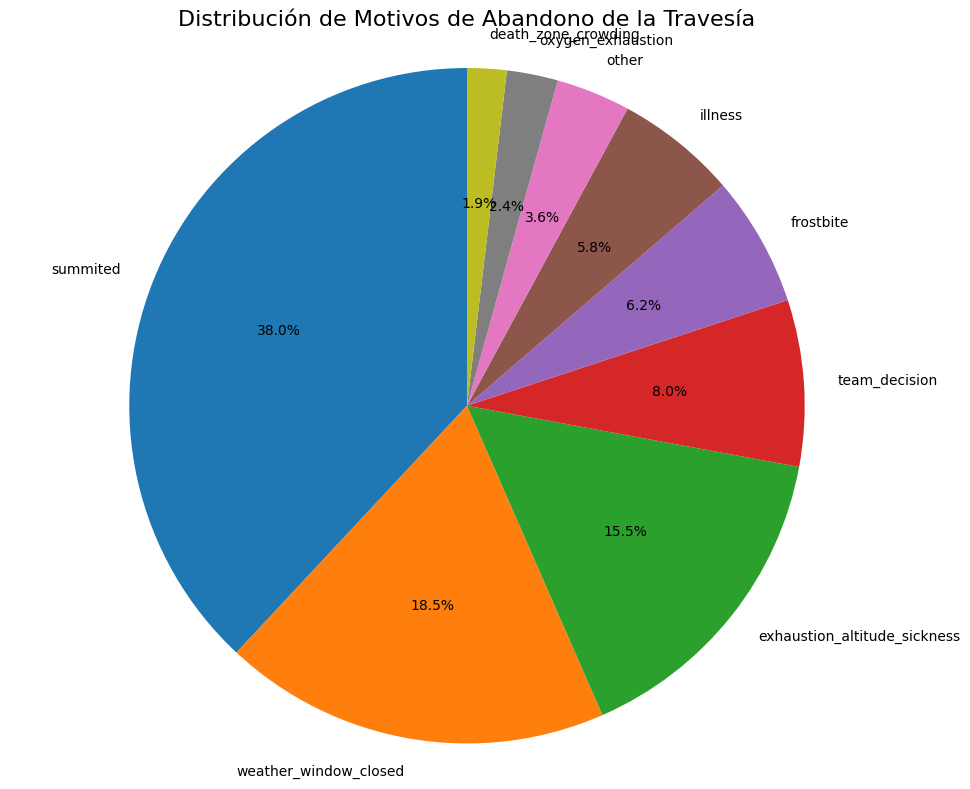

In [166]:
# Calcular la frecuencia de cada motivo de abandono
turnaround_counts = df_analisis['turnaround_reason'].value_counts()

# Crear el gráfico de tarta
plt.figure(figsize=(10, 8))
plt.pie(turnaround_counts, labels=turnaround_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de Motivos de Abandono de la Travesía', fontsize=16)
plt.axis('equal') # Para asegurar que el gráfico de tarta sea circular.
plt.tight_layout()
plt.show()

#Se ve que el mayor motivo de fracaso se debe a "ventana climática cerrada"(Correspondiente a que el clima no lo permitía)
#Luego continúa la decisión grupal y agotamiento o mal de altura.

Respondiendo la Pregunta, se ve que las causas climáticas lideran el motivo por el cual no se puede llegar a la meta, seguido de la decisión grupal por sentido común y el malestar físico de las personas.

##Conclusiones.


El trabajo resulta interesante para averiguar que factores se deben evitar y tener en cuenta al momento de llevar a cabo un reto tan dificil.
Uno pensaría que las excursiones, con el pasar de los años, la experiencia y los avances tegnológicos, se volverían más fáciles y prácticas, sin embargo el riesgo no bajó e incluso aumentó con el pasar de los años.
El estudio también ayudó a comprender que si bien uno puede tomar recaudos, como el de la estación y la ruta ideal para recorrer, existen factores como el cambio repentino del tiempo y del mismo cuerpo que no pueden controlarse y pueden presentarse en la travesía.

Estoy seguro de que es posible conseguir más información y averiguar más factores que deben tomarse en cuenta para llevar a cabo esta tarea, sin embargo por el momento es una buena introdicción al tema.